In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('../data/simulated_neutrino_events.csv')
X = df.drop('label', axis = 1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 7, stratify= y)

model = RandomForestClassifier(random_state=7)
model.fit(X_train, y_train)

print("model trained")

model trained


cm


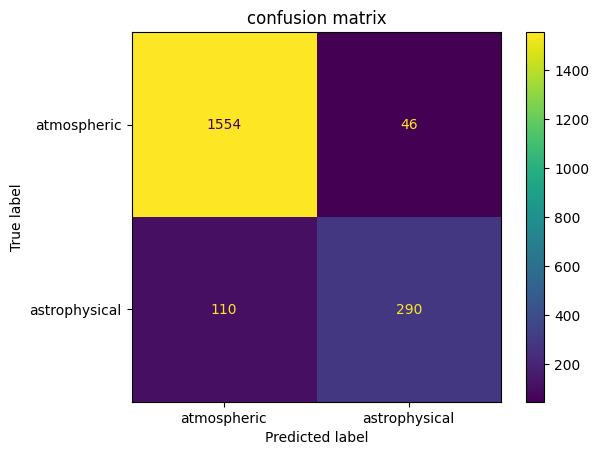

In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("cm")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['atmospheric', 'astrophysical'])
disp.plot()
plt.title("confusion matrix")
plt.show()


In [3]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=['Atmospheric', 'Astrophysical'])

print(report)

               precision    recall  f1-score   support

  Atmospheric       0.93      0.97      0.95      1600
Astrophysical       0.86      0.72      0.79       400

     accuracy                           0.92      2000
    macro avg       0.90      0.85      0.87      2000
 weighted avg       0.92      0.92      0.92      2000



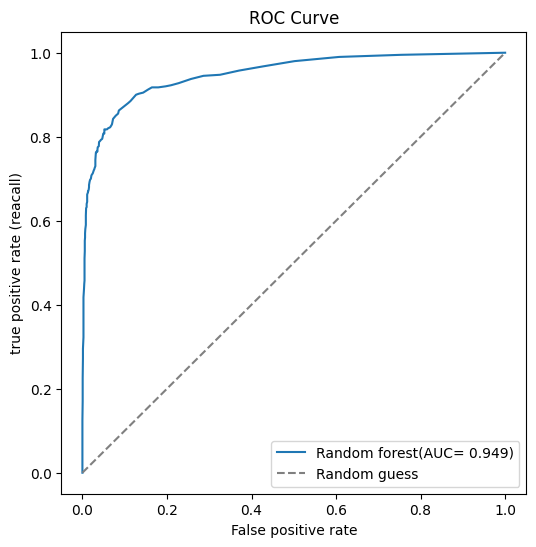

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, threshholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label= f'Random forest(AUC= {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle = '--', color = 'grey', label = 'Random guess')
plt.xlabel('False positive rate')
plt.ylabel('true positive rate (reacall)')
plt.title('ROC Curve')
plt.legend()
plt.show()
           

        feature  importance
0        energy    0.421091
4      dom_hits    0.161347
3  track_length    0.130667
1        zenith    0.086311
6   time_spread    0.084924
5  reco_quality    0.060870
2       azimuth    0.054790


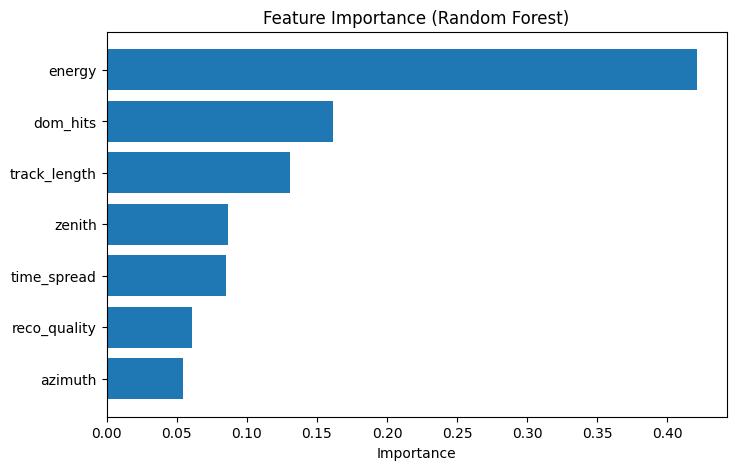

In [6]:
importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)
print(importance_df)

plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.show()